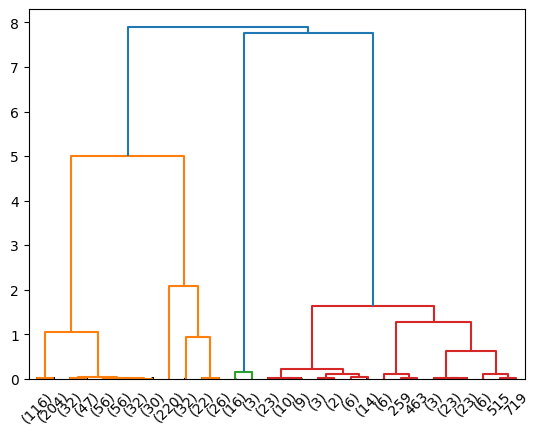

In [1]:
# Scipy 3000'den fazla zaman serisi olduğu zaman max recursion depth hatası veriyor.
# Örnek olarak kalması için Arms Race modelini buraya ekledim, makul sayıda zaman serisi için hızlı bir şekilde çalışıyor.

import numpy as np
from simclstr.plotting import interactive_plot_clusters, multiple_tabs_interactive_plot_clusters, plot_clusters
from simclstr.clusterer import read_time_series, perform_clustering, simulate_from_vensim
from print_distances import print_distances
import os

model_path = os.path.expanduser('data_files/arms race.mdl')

parameter_set = {"initial arms expenditure A": [200, 400],
                "initial arms expenditure B": [200, 400],
                "fear responsiveness A": [1, 4],
                "fear responsiveness B": [1, 4],
                "grievance A": [0, 5],
                "grievance B": [0, 5],
                "restraint A": [1, 4],
                "restraint B": [1, 4],
                "perception delay time of A": [1, 4],
                "perception delay time of B": [1, 4]
                }

output_of_interest = 'arms expenditure A'

simulation_results = simulate_from_vensim(model_path, parameter_set, output_of_interest)

clustering_results = perform_clustering(simulation_results, distance='pattern_wdtw', cMethod='maxclust', cValue = 6, plotDendrogram=True, transform='normalize')

In [2]:
multiple_tabs_interactive_plot_clusters(clustering_results[1], 'pattern_wdtw')

           307       528       988       786      1011      1008
           307       528       988       786      1011      1008
 307       0.0  0.008939  0.000836  0.000882  0.998962  1.008682
 528  0.008939       0.0  0.000196  0.000221  1.001392  1.002225
 988  0.000836  0.000196       0.0  0.000043  0.999396   1.00071
 786  0.000882  0.000221  0.000043       0.0  0.999398  1.001415
1011  0.998962  1.001392  0.999396  0.999398       0.0  0.000004
1008  1.008682  1.002225   1.00071  1.001415  0.000004       0.0


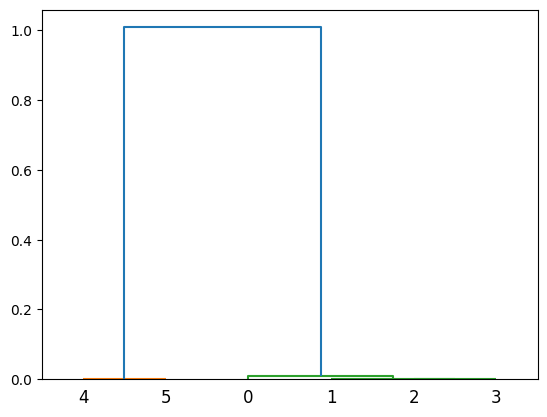

In [3]:
print_distances(clustering_results[0], [307, 528, 988, 786, 1011, 1008])

submatrix = [time_series for time_series in simulation_results if time_series.index in [307, 528, 988, 786, 1011, 1008]]

submatrix_clustering_results = perform_clustering(submatrix, distance='pattern_wdtw', cMethod='maxclust', cValue = 1, plotDendrogram=True, transform='normalize')

In [4]:
multiple_tabs_interactive_plot_clusters(submatrix_clustering_results[1], 'pattern_wdtw', port = 8052)